Temperature-profile blocks used: [390000, 420000, 450000]
Fitted chunk range: 22 to 32
Temperature gradient dT/dz = 0.0752669816324602 K/Angstrom


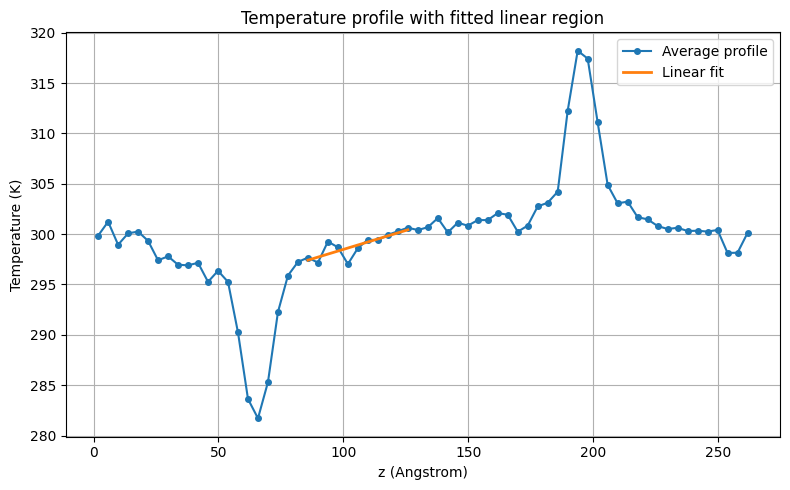

Slope of f_HOT = -0.015025189157414999 eV/step
Slope of f_COLD = 0.014891031554056888 eV/step
Average energy rate = 0.014958110355735944 eV/step
Heat input rate Qdot = 14.958110355735943 eV/ps


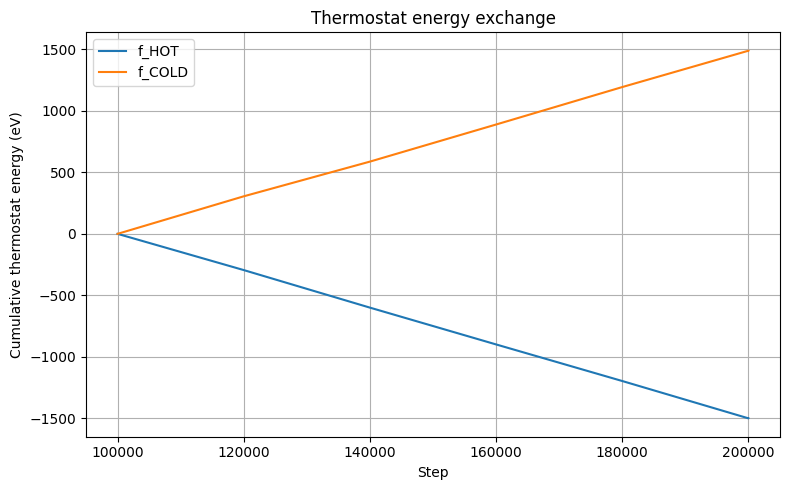

Cross-sectional area A = 2957.1779831634813 Angstrom^2
Heat flux J = 0.0025291190521671445 eV/(ps*Angstrom^2)
Thermal conductivity k = 0.03360197256902378 eV/(ps*Angstrom*K)
Thermal conductivity k = 53.83629530639885 W/m-K


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# User settings
# ============================================================
thermo_file = "thermo.csv"
temp_profile_file = "temp.profile.direct"

# Number of last temperature-profile blocks to average
n_last_blocks = 3

# Choose the chunk range for the linear fit
fit_chunk_min = 22
fit_chunk_max = 32

# Use later part of thermo.csv for fitting thermostat energy slopes
step_fit_start = 40000

# Unit conversion:
# 1 eV / (ps·Angstrom·K) = 1602.176634 W/m·K
EV_PER_PS_A_TO_WMK = 1602.176634

# Timestep in ps (LAMMPS metal units)
timestep = 0.001


# ============================================================
# Part 1: Read temp.profile.direct
# ============================================================
with open(temp_profile_file, "r") as f:
    lines = f.readlines()

blocks = {}
i = 0

while i < len(lines):
    line = lines[i].strip()

    if not line or line.startswith("#"):
        i += 1
        continue

    parts = line.split()

    # Block header format: timestep, number_of_chunks, total_count
    if len(parts) == 3:
        try:
            step = int(float(parts[0]))
            nchunk = int(float(parts[1]))
            _ = float(parts[2])
        except ValueError:
            i += 1
            continue

        data = []
        for _ in range(nchunk):
            i += 1
            values = lines[i].split()

            data.append([
                int(values[0]),      # chunk index
                float(values[1]),    # z coordinate
                float(values[2]),    # atom count
                float(values[3])     # temperature
            ])

        blocks[step] = pd.DataFrame(
            data,
            columns=["chunk", "coord", "ncount", "temp"]
        )

    i += 1

all_profile_steps = sorted(blocks.keys())
selected_steps = all_profile_steps[-n_last_blocks:]

df_all = pd.concat(
    [blocks[step].assign(step=step) for step in selected_steps],
    ignore_index=True
)

avg_profile = (
    df_all.groupby("chunk", as_index=False)
    .agg(
        coord=("coord", "mean"),
        ncount=("ncount", "mean"),
        temp=("temp", "mean")
    )
)

# ============================================================
# Part 2: Fit temperature gradient
# ============================================================
fit_df = avg_profile[
    (avg_profile["chunk"] >= fit_chunk_min) &
    (avg_profile["chunk"] <= fit_chunk_max)
].copy()

x = fit_df["coord"].values
y = fit_df["temp"].values

slope, intercept = np.polyfit(x, y, 1)
temperature_gradient = slope   # K/Angstrom

print("Temperature-profile blocks used:", selected_steps)
print(f"Fitted chunk range: {fit_chunk_min} to {fit_chunk_max}")
print("Temperature gradient dT/dz =", temperature_gradient, "K/Angstrom")

plt.figure(figsize=(8, 5))
plt.plot(avg_profile["coord"], avg_profile["temp"], "o-", ms=4, label="Average profile")
plt.plot(x, slope * x + intercept, "-", lw=2, label="Linear fit")
plt.xlabel("z (Angstrom)")
plt.ylabel("Temperature (K)")
plt.title("Temperature profile with fitted linear region")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Part 3: Read thermo.csv
# ============================================================
thermo_df = pd.read_csv(
    thermo_file,
    names=["step", "temp", "lx", "ly", "lz", "f_hot", "f_cold"]
)

# ============================================================
# Part 4: Fit thermostat energy slopes
# ============================================================
fit_thermo_df = thermo_df[thermo_df["step"] >= step_fit_start].copy()

hot_slope, hot_intercept = np.polyfit(
    fit_thermo_df["step"], fit_thermo_df["f_hot"], 1
)

cold_slope, cold_intercept = np.polyfit(
    fit_thermo_df["step"], fit_thermo_df["f_cold"], 1
)

# Average absolute slope in eV/step
energy_rate_per_step = 0.5 * (abs(hot_slope) + abs(cold_slope))

# Convert to eV/ps
heat_rate = energy_rate_per_step / timestep

print("Slope of f_HOT =", hot_slope, "eV/step")
print("Slope of f_COLD =", cold_slope, "eV/step")
print("Average energy rate =", energy_rate_per_step, "eV/step")
print("Heat input rate Qdot =", heat_rate, "eV/ps")

plt.figure(figsize=(8, 5))
plt.plot(thermo_df["step"], thermo_df["f_hot"], label="f_HOT")
plt.plot(thermo_df["step"], thermo_df["f_cold"], label="f_COLD")
plt.xlabel("Step")
plt.ylabel("Cumulative thermostat energy (eV)")
plt.title("Thermostat energy exchange")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Part 5: Calculate thermal conductivity
# ============================================================
lx = thermo_df["lx"].iloc[-1]
ly = thermo_df["ly"].iloc[-1]
cross_section_area = lx * ly   # Angstrom^2

# Factor of 2 for two heat-flow directions in periodic setup
heat_flux = heat_rate / (2.0 * cross_section_area)

thermal_conductivity_metal = heat_flux / abs(temperature_gradient)
thermal_conductivity_wmk = thermal_conductivity_metal * EV_PER_PS_A_TO_WMK

print("Cross-sectional area A =", cross_section_area, "Angstrom^2")
print("Heat flux J =", heat_flux, "eV/(ps*Angstrom^2)")
print("Thermal conductivity k =", thermal_conductivity_metal, "eV/(ps*Angstrom*K)")
print("Thermal conductivity k =", thermal_conductivity_wmk, "W/m-K")